# 🛡️ Modélisation Avancée IDS (NSL-KDD)

Ce notebook contient l'implémentation finale du projet, incluant :
- **L'Analyse Exploratoire des Données (EDA)** : distribution des classes, boxplots des features, matrice de corrélation.
- La gestion du déséquilibre extrême avec **SMOTE**.
- La validation croisée stricte avec `imblearn.pipeline.Pipeline` (Zero Data Leakage).
- L'optimisation des hyperparamètres avec **RandomizedSearchCV**.
- Le benchmark de latence Temps Réel (Preuve de concept NVIDIA Morpheus).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    f1_score, roc_curve, auc, precision_recall_fscore_support
)
import xgboost as xgb
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
import joblib
import time
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
CLASS_NAMES = {0: 'Normal', 1: 'DoS', 2: 'Probe', 3: 'R2L', 4: 'U2R'}
CLASS_LABELS = ['Normal', 'DoS', 'Probe', 'R2L', 'U2R']
COLORS = ['#2ecc71', '#e74c3c', '#f39c12', '#9b59b6', '#e67e22']

## 1. Chargement et Preprocessing des Données

In [2]:
columns = [
    'duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes',
    'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in',
    'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations',
    'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login',
    'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate',
    'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate',
    'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count',
    'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
    'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate',
    'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'label', 'difficulty_level'
]

train_df = pd.read_csv('../data/KDDTrain+.txt', names=columns)
test_df = pd.read_csv('../data/KDDTest+.txt', names=columns)
train_df = train_df.drop('difficulty_level', axis=1)
test_df = test_df.drop('difficulty_level', axis=1)

attack_mapping = {
    'neptune': 'DoS', 'smurf': 'DoS', 'back': 'DoS', 'teardrop': 'DoS', 'pod': 'DoS', 'land': 'DoS',
    'satan': 'Probe', 'ipsweep': 'Probe', 'portsweep': 'Probe', 'nmap': 'Probe',
    'warezclient': 'R2L', 'guess_passwd': 'R2L', 'warezmaster': 'R2L', 'imap': 'R2L',
    'ftp_write': 'R2L', 'multihop': 'R2L', 'phf': 'R2L', 'spy': 'R2L',
    'buffer_overflow': 'U2R', 'rootkit': 'U2R', 'loadmodule': 'U2R', 'perl': 'U2R',
    'normal': 'Normal',
    'apache2': 'DoS', 'udpstorm': 'DoS', 'processtable': 'DoS', 'mailbomb': 'DoS', 'worm': 'DoS',
    'mscan': 'Probe', 'saint': 'Probe',
    'snmpgetattack': 'R2L', 'snmpguess': 'R2L', 'sendmail': 'R2L', 'named': 'R2L',
    'xlock': 'R2L', 'xsnoop': 'R2L', 'httptunnel': 'R2L',
    'ps': 'U2R', 'xterm': 'U2R', 'sqlattack': 'U2R'
}

train_df['attack_class'] = train_df['label'].map(attack_mapping)
test_df['attack_class'] = test_df['label'].map(attack_mapping)
train_df = train_df.drop('label', axis=1)
test_df = test_df.drop('label', axis=1)

class_mapping = {'Normal': 0, 'DoS': 1, 'Probe': 2, 'R2L': 3, 'U2R': 4}
train_df['attack_class'] = train_df['attack_class'].map(class_mapping)
test_df['attack_class'] = test_df['attack_class'].map(class_mapping)


## 2. Analyse Exploratoire des Données (EDA)
Avant de modéliser, visualisons la distribution des classes et le comportement de certaines variables.

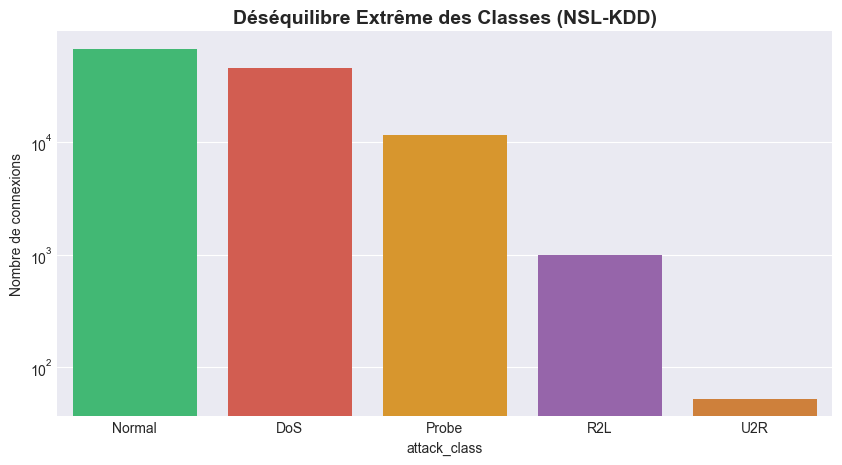

In [3]:
# 1. Distribution des classes
plt.figure(figsize=(10, 5))
sns.countplot(data=train_df, x='attack_class', palette=COLORS)
plt.title('Déséquilibre Extrême des Classes (NSL-KDD)', fontsize=14, fontweight='bold')
plt.xticks(ticks=range(5), labels=CLASS_LABELS)
plt.ylabel('Nombre de connexions')
plt.yscale('log') # Echelle log pour voir U2R
plt.show()

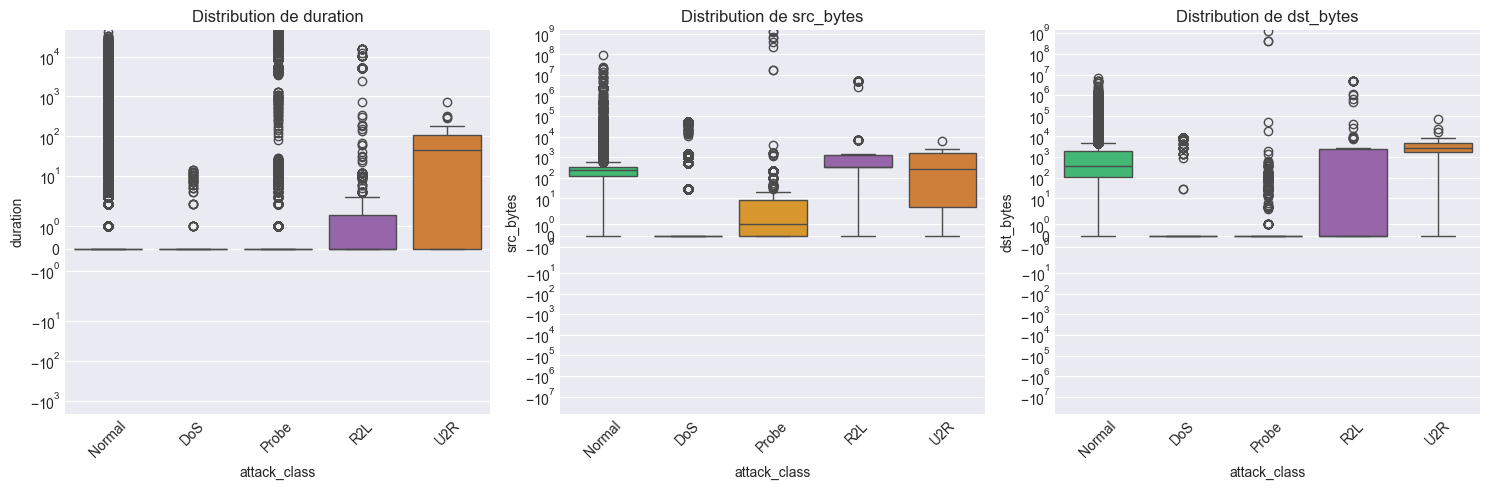

In [4]:
# 2. Boxplots des features numériques clés
key_features = ['duration', 'src_bytes', 'dst_bytes']
plt.figure(figsize=(15, 5))
for i, feature in enumerate(key_features, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(data=train_df, x='attack_class', y=feature, palette=COLORS)
    plt.yscale('symlog') # Echelle log pour les valeurs extrêmes
    plt.xticks(ticks=range(5), labels=CLASS_LABELS, rotation=45)
    plt.title(f'Distribution de {feature}')
plt.tight_layout()
plt.show()

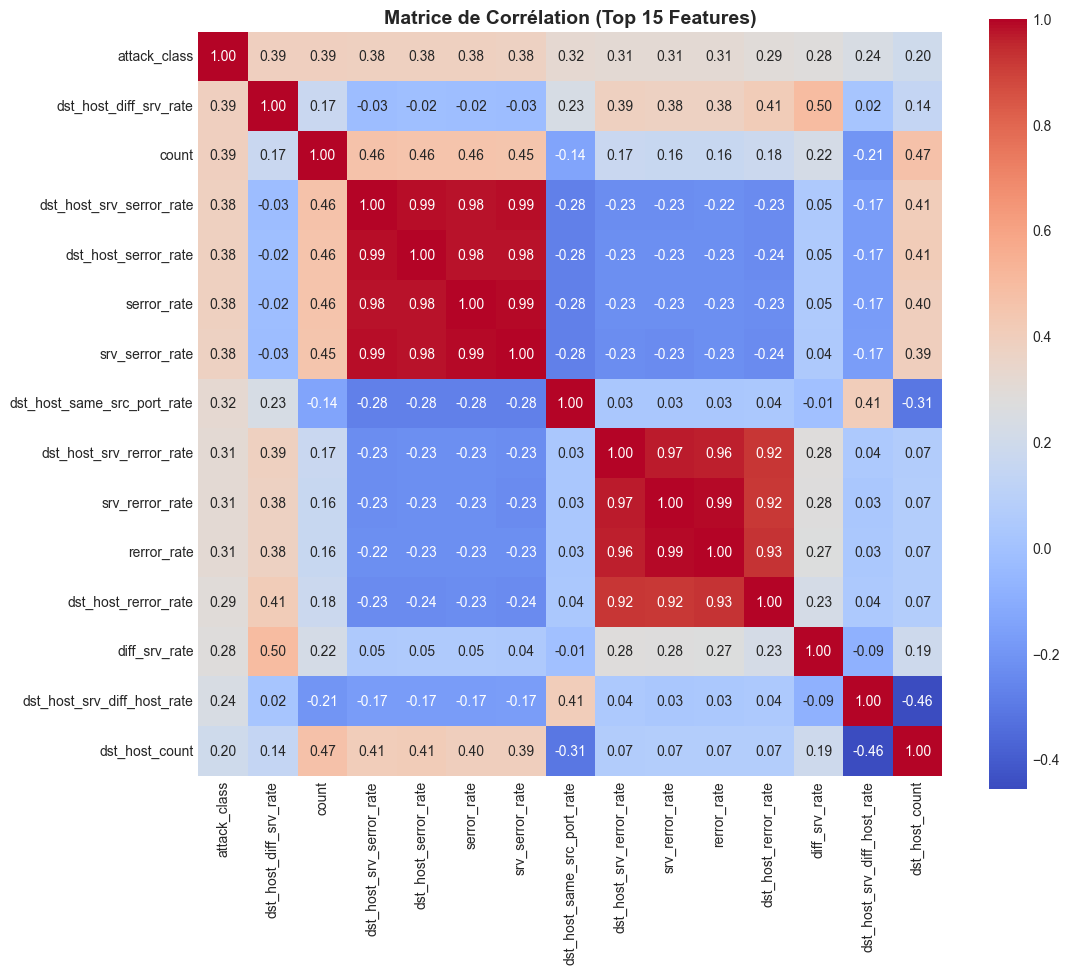

In [5]:
# 3. Matrice de corrélation (Top 15 features les plus corrélées à la cible)
plt.figure(figsize=(12, 10))
numeric_df = train_df.select_dtypes(include=[np.number])
corr = numeric_df.corr()
# On prend les 15 variables les plus corrélées avec 'attack_class'
top_cols = corr.nlargest(15, 'attack_class')['attack_class'].index
cm = np.corrcoef(numeric_df[top_cols].values.T)
sns.heatmap(cm, annot=True, square=True, fmt='.2f', annot_kws={'size': 10},
            yticklabels=top_cols.values, xticklabels=top_cols.values, cmap='coolwarm')
plt.title('Matrice de Corrélation (Top 15 Features)', fontsize=14, fontweight='bold')
plt.show()

## 3. Préparation pour la Modélisation

In [6]:
y_train = train_df['attack_class']
y_test = test_df['attack_class']
X_train_raw = train_df.drop(['attack_class'], axis=1)
X_test_raw = test_df.drop(['attack_class'], axis=1)

categorical_cols = ['protocol_type', 'service', 'flag']
X_train = pd.get_dummies(X_train_raw, columns=categorical_cols)
X_test = pd.get_dummies(X_test_raw, columns=categorical_cols)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_train.columns)
joblib.dump(list(X_train.columns), '../models/model_columns.pkl')
print(f"Preprocessing terminé. Forme : {X_train_scaled.shape}")

Preprocessing terminé. Forme : (125973, 122)


## 4. Modèle XGBoost avec SMOTE
Nous encapsulons le SMOTE et XGBoost dans un pipeline `imblearn` pour éviter toute fuite d'informations (Data Leakage) lors du `StratifiedKFold`.

In [7]:
cv_strategy = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

xgb_pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('classifier', xgb.XGBClassifier(
        objective='multi:softprob', num_class=5, eval_metric='mlogloss',
        random_state=42, verbosity=0, n_jobs=1
    ))
])

xgb_param_grid = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__max_depth': [6, 10, 15],
    'classifier__learning_rate': [0.01, 0.1, 0.2]
}

xgb_search = RandomizedSearchCV(
    xgb_pipeline, param_distributions=xgb_param_grid, 
    n_iter=5, cv=cv_strategy, scoring='f1_macro', 
    n_jobs=-1, verbose=1, random_state=42
)

xgb_search.fit(X_train_scaled, y_train)
best_xgb = xgb_search.best_estimator_
xgb_y_pred = best_xgb.predict(X_test_scaled)

print(f"Meilleur score CV (F1 Macro) : {xgb_search.best_score_:.4f}")
print(classification_report(y_test, xgb_y_pred, target_names=CLASS_LABELS))

Fitting 3 folds for each of 5 candidates, totalling 15 fits


Meilleur score CV (F1 Macro) : 0.9406
              precision    recall  f1-score   support

      Normal       0.70      0.97      0.81      9711
         DoS       0.97      0.82      0.89      7460
       Probe       0.79      0.73      0.76      2421
         R2L       0.97      0.13      0.23      2885
         U2R       0.70      0.34      0.46        67

    accuracy                           0.79     22544
   macro avg       0.82      0.60      0.63     22544
weighted avg       0.83      0.79      0.76     22544



## 5. Benchmark de Latence (Simulation Temps Réel)
Vérification de la capacité du modèle à tenir la charge d'un réseau en direct.

In [8]:
def benchmark_latency(model, X_test, num_samples):
    if num_samples <= len(X_test):
        X_sample = X_test.sample(n=num_samples, random_state=42)
    else:
        X_sample = X_test.sample(n=num_samples, replace=True, random_state=42)
        
    start_time = time.perf_counter()
    model.predict(X_sample)
    end_time = time.perf_counter()
    
    latency_ms = (end_time - start_time) * 1000
    print(f"Batch de {num_samples:5d} connexion(s) : {latency_ms:6.2f} ms")

benchmark_latency(best_xgb, X_test_scaled, 1)
benchmark_latency(best_xgb, X_test_scaled, 1000)
benchmark_latency(best_xgb, X_test_scaled, 10000)

Batch de     1 connexion(s) :   8.25 ms
Batch de  1000 connexion(s) :  25.58 ms


Batch de 10000 connexion(s) : 178.39 ms
